In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
DATASET_FILTER = "approved" # "approved" or "all_decisions"

DATASET_DIR = f"./../data/datasets/1995/{DATASET_FILTER}"

EMA = f"{DATASET_DIR}/EMA.csv"
PMDA = f"{DATASET_DIR}/PMDA.csv"
SWISSMEDIC = f"{DATASET_DIR}/Swissmedic.csv"
TGA = f"{DATASET_DIR}/TGA.csv"
FDA = f"{DATASET_DIR}/FDA.csv"
HEALTHCANADA = f"{DATASET_DIR}/HealthCanada.csv"
OVERALL = f"{DATASET_DIR}/Overall.csv"

In [48]:
ema = pd.read_csv(EMA)
pmda = pd.read_csv(PMDA)
swissmedic = pd.read_csv(SWISSMEDIC)
tga = pd.read_csv(TGA)
fda = pd.read_csv(FDA)
healthcanada = pd.read_csv(HEALTHCANADA)
overall = pd.read_csv(OVERALL)

In [49]:
overall.head(3)

,Marketing_authorisation_number,Procedure_number,Drug_name,Non_proprietary_name,Marketing_authorisation_holder,Drug_class,Pharmaceutical_form,Administration_route,Decision,Current_status,...,Nonclinical_abridged,Referral_body,Document_name,Marketing_authorisation_holder_extracted,Agency,Indications_and_usage,Origin,Referral,Disease_name(s),DRUG_CODE
0,ema/515905/2024,emea/h/c/006295/0000,wainzua,eplontersen,astrazeneca ab,peptides and proteins,solution,subcutaneous,approved,authorised,...,no,na,wainzua-epar-public-assessment-report_en.pdf,astrazeneca,EMA,NaN,NaN,NaN,NaN,NaN
1,ema/871459/2022,emea/h/c/005483/0000,pluvicto,lutetium (177lu) vipivotide tetraxetan,novartis europharm limited,other,solution,intravenous,approved,authorised,...,no,na,pluvicto-epar-public-assessment-report_en.pdf,novartis,EMA,NaN,NaN,NaN,NaN,NaN
2,ema/549260/2023,emea/h/c/006101/0000,uzpruvo,ustekinumab,stada arzneimittel ag,biologics,solution,subcutaneous,approved,authorised,...,no,na,uzprovo-epar-public-assessment-report_en.pdf,stada,EMA,NaN,NaN,NaN,NaN,NaN


In [50]:
# create a subset df with drug names which appear multiple times within the SAME agency (grouped by agency)
duplicates_within_agency = overall[overall.duplicated(subset=['Drug_name', 'Agency'], keep=False)]
duplicates_within_agency.head(10)

,Marketing_authorisation_number,Procedure_number,Drug_name,Non_proprietary_name,Marketing_authorisation_holder,Drug_class,Pharmaceutical_form,Administration_route,Decision,Current_status,...,Nonclinical_abridged,Referral_body,Document_name,Marketing_authorisation_holder_extracted,Agency,Indications_and_usage,Origin,Referral,Disease_name(s),DRUG_CODE
383,ema/000309/2007,emea/h/c/000309,sb309,epoetin zeta,norbitec gmbh,biologics,solution,intravenous; subcutaneous,approved,authorised,...,no,na,silapo-epar-scientific-discussion_en.pdf,norbitec,EMA,NaN,NaN,NaN,NaN,NaN
1436,ema/309/2007,emea/h/c/309,sb309,epoetin zeta,norbitec gmbh,biologics,solution,intravenous; subcutaneous,approved,authorised,...,no,na,retacrit-epar-scientific-discussion_en.pdf,norbitec,EMA,NaN,NaN,NaN,NaN,NaN
1493,NaN,NaN,inavir,laninamivir octanoate hydrate,"daiichi sankyo company, limited",small molecule,suspension,inhalation,approved,authorised,...,yes,NaN,000239716.pdf,daiichi sankyo,PMDA,NaN,NaN,NaN,NaN,NaN
1496,NaN,NaN,vyvgart,efgartigimod alfa,argenx japan k.k.,biologics,injection,intravenous,approved,authorised,...,yes,NaN,000273743.pdf,argenx,PMDA,NaN,NaN,NaN,NaN,NaN
1504,NaN,NaN,vyndaqel,tafamidis meglumine,pfizer japan inc.,small molecule,capsule,oral,approved,authorised,...,yes,NaN,000237869.pdf,pfizer,PMDA,NaN,NaN,NaN,NaN,NaN
1507,NaN,NaN,benlysta,belimumab,glaxosmithkline k.k.,biologics,powder,intravenous,approved,authorised,...,yes,NaN,000235893.pdf,glaxosmithkline,PMDA,NaN,NaN,NaN,NaN,NaN
1508,NaN,NaN,opdivo,nivolumab,"ono pharmaceutical co., ltd.",biologics,injection,intravenous,approved,authorised,...,yes,NaN,000223203.pdf,ono,PMDA,NaN,NaN,NaN,NaN,NaN
1509,NaN,NaN,olumiant,baricitinib,eli lilly japan k.k.,small molecule,tablet,oral,approved,authorised,...,no,na,000242825.pdf,eli lilly,PMDA,NaN,NaN,NaN,NaN,NaN
1514,NaN,NaN,opdivo,nivolumab,"ono pharmaceutical co., ltd.",biologics,injection,intravenous,approved,authorised,...,yes,NaN,000223201.pdf,ono,PMDA,NaN,NaN,NaN,NaN,NaN
1515,NaN,NaN,actemra,tocilizumab,"chugai pharmaceutical co., ltd.",biologics,concentrate,intravenous,approved,authorised,...,yes,NaN,000246328.pdf,chugai,PMDA,NaN,NaN,NaN,NaN,NaN


In [51]:
# find drug names which are cross-agency duplicates (appear in multiple different agencies)
cross_agency_duplicates = overall[overall.duplicated(subset=['Drug_name'], keep=False)]
# drop in-agency duplicates from this subset to keep only cross-agency duplicates
cross_agency_duplicates = cross_agency_duplicates[~cross_agency_duplicates.index.isin(duplicates_within_agency.index)]
cross_agency_duplicates.head(10)

,Marketing_authorisation_number,Procedure_number,Drug_name,Non_proprietary_name,Marketing_authorisation_holder,Drug_class,Pharmaceutical_form,Administration_route,Decision,Current_status,...,Nonclinical_abridged,Referral_body,Document_name,Marketing_authorisation_holder_extracted,Agency,Indications_and_usage,Origin,Referral,Disease_name(s),DRUG_CODE
1,ema/871459/2022,emea/h/c/005483/0000,pluvicto,lutetium (177lu) vipivotide tetraxetan,novartis europharm limited,other,solution,intravenous,approved,authorised,...,no,na,pluvicto-epar-public-assessment-report_en.pdf,novartis,EMA,NaN,NaN,NaN,NaN,NaN
6,ema/821709/2018,emea/h/c/004747/0000,pifeltro,doravirine,merck sharp & dohme b.v.,small molecule,tablet,oral,approved,authorised,...,no,na,pifeltro-epar-public-assessment-report_en.pdf,merck sharp & dohme,EMA,NaN,NaN,NaN,NaN,NaN
7,ema/000400/2001,emea/h/c/000400,zometa,zoledronic acid,novartis,small molecule,powder,intravenous,approved,authorised,...,no,na,zometa-epar-scientific-discussion_en.pdf,novartis,EMA,NaN,NaN,NaN,NaN,NaN
9,ema/55567/2014,emea/h/c/002552,deltyba,delamanid,otsuka novel products gmbh,small molecule,tablet,oral,conditional marketing authorisation,authorised,...,no,na,deltyba-epar-public-assessment-report_en.pdf,otsuka,EMA,NaN,NaN,NaN,NaN,NaN
14,ema/810499/2018,emea/h/c/004916/0000,ogivri,trastuzumab,mylan s.a.s,biologics,powder,intravenous,approved,authorised,...,no,na,ogivri-epar-public-assessment-report_en.pdf,mylan,EMA,NaN,NaN,NaN,NaN,NaN
17,NaN,emea/h/c/000944,xarelto,rivaroxaban,bayer healthcare ag,small molecule,tablet,oral,approved,authorised,...,no,na,xarelto-epar-public-assessment-report_en.pdf,bayer,EMA,NaN,NaN,NaN,NaN,NaN
18,ema/002015/2011,emea/h/c/002015,benlysta,belimumab,glaxo group limited,biologics,powder,intravenous,approved,authorised,...,no,na,benlysta-epar-public-assessment-report_en.pdf,glaxo,EMA,NaN,NaN,NaN,NaN,NaN
20,ema/596950/2015,emea/h/c/002734/0000,cresemba,isavuconazole,basilea medical ltd,small molecule,powder; capsule,intravenous; oral,approved,authorised,...,no,na,cresemba-epar-public-assessment-report_en.pdf,basilea,EMA,NaN,NaN,NaN,NaN,NaN
25,ema/000574/2008,emea/h/c/000860,isentress,raltegravir,merck sharp & dohme ltd,small molecule,tablet,oral,conditional marketing authorisation,authorised,...,no,na,isentress-epar-scientific-discussion_en.pdf,merck sharp & dohme,EMA,NaN,NaN,NaN,NaN,NaN
30,ema/324336/2014,emea/h/c/003843/0000,zydelig,idelalisib,gilead sciences international ltd,small molecule,tablet,oral,approved,authorised,...,no,na,zydelig-epar-public-assessment-report_en.pdf,gilead,EMA,NaN,NaN,NaN,NaN,NaN


In [52]:

print(20 * "-")
print(f"{len(overall):<10} Length of the combined (overall) dataset including all datapoints")
print(f"{len(duplicates_within_agency):<10} Length of the subset including in-agency duplicates (drug names present multiple times within the same agency)")
print(f"{len(cross_agency_duplicates):<10} Length of the subset including cross-agency duplicates (drug names present in multiple different agencies)")
print(20 * "-")
print(f"{overall['Drug_name'].nunique():<10} N of unique drug names in the combined dataset")
print(f"{duplicates_within_agency['Drug_name'].nunique():<10} N of unique drug names in the in-agency duplicates subset")
print(f"{cross_agency_duplicates['Drug_name'].nunique():<10} N of unique drug names in the cross-agency duplicates subset")

--------------------
31964      Length of the combined (overall) dataset including all datapoints
22631      Length of the subset including in-agency duplicates (drug names present multiple times within the same agency)
2823       Length of the subset including cross-agency duplicates (drug names present in multiple different agencies)
--------------------
10756      N of unique drug names in the combined dataset
3566       N of unique drug names in the in-agency duplicates subset
1217       N of unique drug names in the cross-agency duplicates subset


## Network Visualization: Drug Names Shared Across Agencies

In [54]:
import networkx as nx
from itertools import combinations
import numpy as np

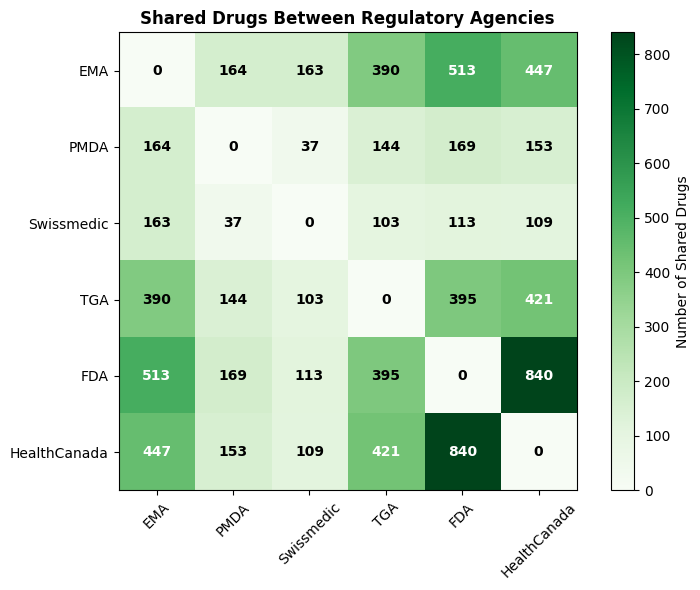

In [67]:
# Create a heatmap showing how many drugs each pair of agencies share
# use numbers within heatmap tiles

agencies = overall['Agency'].unique()
total_unique_drugs = overall['Drug_name'].nunique()
heatmap = heatmap / total_unique_drugs
heatmap = pd.DataFrame(0, index=agencies, columns=agencies)
for drug in overall['Drug_name'].unique():
    involved_agencies = overall[overall['Drug_name'] == drug]['Agency'].unique()
    for agency1, agency2 in combinations(involved_agencies, 2):
        heatmap.loc[agency1, agency2] += 1
        heatmap.loc[agency2, agency1] += 1

plt.figure(figsize=(8, 6))
plt.imshow(heatmap, cmap='Greens', interpolation='nearest')
plt.colorbar(label='Number of Shared Drugs')
plt.xticks(ticks=np.arange(len(agencies)), labels=agencies, rotation=45)
plt.yticks(ticks=np.arange(len(agencies)), labels=agencies)

# Add text annotations with the actual numbers
for i in range(len(agencies)):
    for j in range(len(agencies)):
        value = heatmap.iloc[i, j]
        # Choose text color based on background intensity
        text_color = 'white' if value > heatmap.values.max() * 0.5 else 'black'
        plt.text(j, i, f'{int(value)}', 
                ha='center', va='center', 
                color=text_color, fontsize=10, fontweight='bold')

plt.title('Shared Drugs Between Regulatory Agencies', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_3484\199241159.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11006711409395974' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_3484\199241159.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5239616613418531' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_3484\199241159.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8402061855670103' has dtype incompatible with int64, please explicitly cast to a co

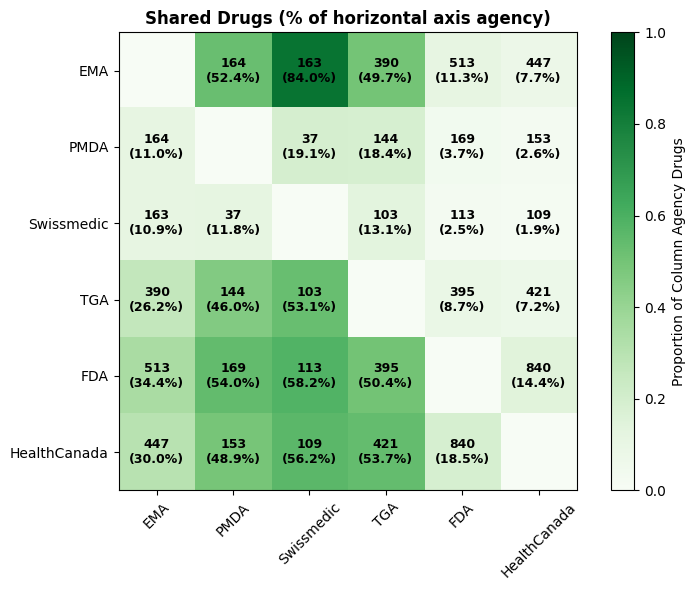

In [72]:
# Create a heatmap showing proportions of shared drugs
# Normalized by the x-axis (column) agency's total drug count

agencies = overall['Agency'].unique()
heatmap = pd.DataFrame(0, index=agencies, columns=agencies)

# Get the total number of drugs per agency
agency_drug_counts = overall.groupby('Agency')['Drug_name'].nunique()

for drug in overall['Drug_name'].unique():
    involved_agencies = overall[overall['Drug_name'] == drug]['Agency'].unique()
    for agency1, agency2 in combinations(involved_agencies, 2):
        heatmap.loc[agency1, agency2] += 1
        heatmap.loc[agency2, agency1] += 1

# Normalize by column (x-axis) agency's total drug count
heatmap_normalized = heatmap.copy()
for j, agency_col in enumerate(agencies):  # j is column (x-axis)
    for i, agency_row in enumerate(agencies):  # i is row (y-axis)
        if i != j:
            # Divide by the column agency's total drugs
            heatmap_normalized.loc[agency_row, agency_col] = (
                heatmap.loc[agency_row, agency_col] / agency_drug_counts[agency_col]
            )

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_normalized, cmap='Greens', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar(label='Proportion of Column Agency Drugs')
plt.xticks(ticks=np.arange(len(agencies)), labels=agencies, rotation=45)
plt.yticks(ticks=np.arange(len(agencies)), labels=agencies)

# Add text with absolute and percentage values
for i in range(len(agencies)):
    for j in range(len(agencies)):
        if i != j:  # Skip diagonal
            abs_value = int(heatmap.iloc[i, j])
            prop_value = heatmap_normalized.iloc[i, j]
            # text_color = 'white' if prop_value > 0.5 else 'black'
            text_color = "black"
            plt.text(j, i, f'{abs_value}\n({prop_value:.1%})', 
                    ha='center', va='center', 
                    color=text_color, fontsize=9, fontweight='bold')

plt.title('Shared Drugs (% of horizontal axis agency)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Find the top shared drugs across multiple agencies and create df subset with them
drug_agency_count = 

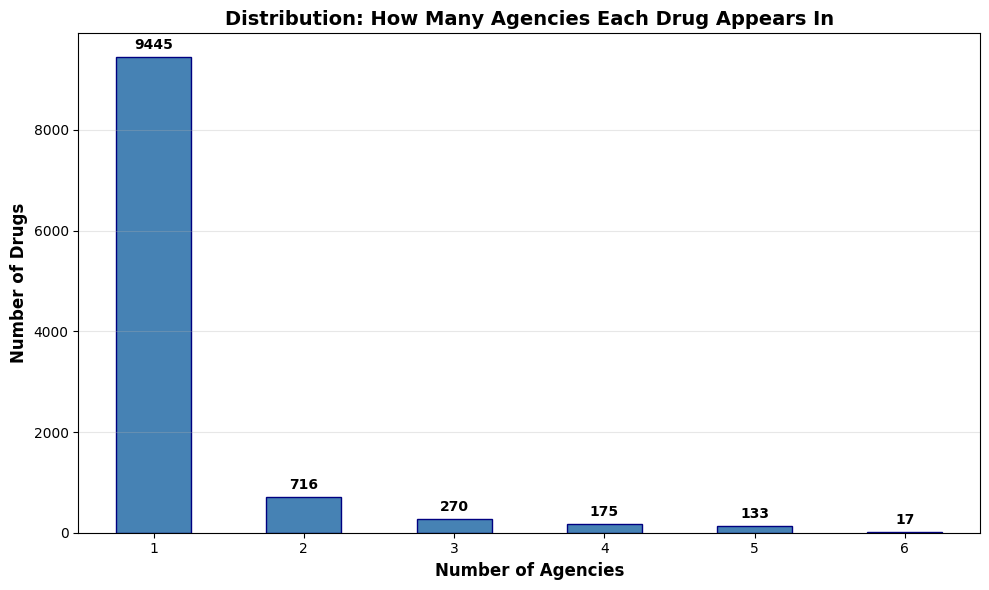

In [61]:
# Visualize the distribution of how many agencies each drug appears in
plt.figure(figsize=(10, 6))

agency_counts = overall.groupby('Drug_name')['Agency'].nunique()
agency_counts.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='navy')

plt.xlabel('Number of Agencies', fontsize=12, fontweight='bold')
plt.ylabel('Number of Drugs', fontsize=12, fontweight='bold')
plt.title('Distribution: How Many Agencies Each Drug Appears In', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(agency_counts.value_counts().sort_index()):
    plt.text(i, v + max(agency_counts.value_counts()) * 0.01, str(v), 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()